## Data Wrangling (Data Cleansing)

### What is the purpose of data wrangling?
- Data wrangling is the process of converting data from the initial format to a format that may be better for analysis.

### What is the fuel consumption (Liter/100k) rate for the diesel car?
#### Import data
 
You can find the "Automobile Dataset" from the following link: https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2021-01-01">https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data
  
We will be using this dataset throughout this course.

### Import pandas

In [1]:
# pandas is the scientific library.
# matplotlib.pyplot/pylab is the data visualiztion library.
import pandas as pd
import matplotlib.pylab as plt

### Reading the dataset from the URL and adding the related headers

First, we assign the URL of the dataset to "filename".  
OR convert imports-85.data to .csv file in ```'Your file location'```

In [2]:
path = "D:\Github\DataAnalysis\Dataset\imports-85.data"
df = pd.read_csv(path, header=None)
df.to_csv("D:\Github\DataAnalysis\Dataset\DataAutomobile.csv", index=False)

filename = "D:\Github\DataAnalysis\Dataset\DataAutomobile.csv"
# filename = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/auto.csv"

Then, we create a Python list **headers** containing name of headers.

In [3]:
headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]

Use the Pandas method **read_csv()** to load the data from the web address/local computer. Set the parameter "names" equal to the Python list "headers".

In [4]:
df = pd.read_csv(filename, names=headers)

Use the method **head()** to display the first five rows of the dataframe.

In [5]:
# To see what the data set looks like, we'll use the head() method.
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,0,1,2,3,4,5,6,7,8,9.0,...,16,17,18,19,20.0,21,22,23,24,25
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
2,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
3,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
4,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950


As we can see, several question marks appeared in the dataframe; those are missing values which may hinder our further analysis.
  
So, how do we identify all those missing values and deal with them?
- Identify missing data
- Deal with missing data
- Correct data format



### Identify and handle missing values
#### Identify missing values
Convert "?" to NaN  

In the car dataset, missing data comes with the question mark "?".  
We replace "?" with NaN (Not a Number), Python's default missing value marker for reasons of computational speed and convenience. Here we use the function: 
```.replace(A, B, inplace = True)``` to replace A by B.


In [6]:
# Before replace ? with NaN, you need to import numpy library.
import numpy as np

# Replace "?" to NaN
df.replace("?", np.nan, inplace = True)
df.head(5)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,0,1,2,3,4,5,6,7,8,9.0,...,16,17,18,19,20.0,21,22,23,24,25
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
2,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
3,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
4,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950


#### Evaluating for Missing Data

The missing values are converted by default. We use the following functions to identify these missing values. There are two methods to detect missing data:

- ```.isnull()```
- ```.notnull()```
 
The output is a boolean value indicating whether the value that is passed into the argument is in fact missing data.


In [7]:
missing_data = df.isnull()
missing_data.head(5)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


```True``` means the value is a **missing value** while ```False``` means the value is **not a missing value.**


#### Count missing values in each column
  
Using a for loop in Python, we can quickly figure out the number of missing values in each column. As mentioned above, ```True``` represents a missing value and ```False``` means the value is present in the dataset. In the body of the for loop the method ```.value_counts()``` counts the number of ```True``` values. 

In [8]:
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")    

symboling
False    206
Name: symboling, dtype: int64

normalized-losses
False    165
True      41
Name: normalized-losses, dtype: int64

make
False    206
Name: make, dtype: int64

fuel-type
False    206
Name: fuel-type, dtype: int64

aspiration
False    206
Name: aspiration, dtype: int64

num-of-doors
False    204
True       2
Name: num-of-doors, dtype: int64

body-style
False    206
Name: body-style, dtype: int64

drive-wheels
False    206
Name: drive-wheels, dtype: int64

engine-location
False    206
Name: engine-location, dtype: int64

wheel-base
False    206
Name: wheel-base, dtype: int64

length
False    206
Name: length, dtype: int64

width
False    206
Name: width, dtype: int64

height
False    206
Name: height, dtype: int64

curb-weight
False    206
Name: curb-weight, dtype: int64

engine-type
False    206
Name: engine-type, dtype: int64

num-of-cylinders
False    206
Name: num-of-cylinders, dtype: int64

engine-size
False    206
Name: engine-size, dtype: int64

fuel-system
Fa

Based on the summary above, each column has 205 rows of data and seven of the columns containing missing data:

1. "normalized-losses": 41 missing data
2. "num-of-doors": 2 missing data
3. "bore": 4 missing data
4. "stroke" : 4 missing data
5. "horsepower": 2 missing data
6. "peak-rpm": 2 missing data
7. "price": 4 missing data



### Deal with missing data
How to deal with missing data?
1. Drop data
    - Drop the whole row
    - Drop the whole column
2. Replace data
    - Replace it by mean
    - Replace it by frequency
    - Replace it based on other functions

Whole columns should be dropped only if most entries in the column are empty. In our dataset, none of the columns are empty enough to drop entirely.  

We have some freedom in choosing which method to replace data; however, some methods may seem more reasonable than others. We will apply each method to many different columns:

1. Replace by mean:
    - "normalized-losses": 41 missing data, replace them with mean
    - "stroke": 4 missing data, replace them with mean
    - "bore": 4 missing data, replace them with mean
    - "horsepower": 2 missing data, replace them with mean
    - "peak-rpm": 2 missing data, replace them with mean
2. Replace by frequency:
    - "num-of-doors": 2 missing data, replace them with "four". 
         - Reason: 84% sedans is four doors. Since four doors is most frequent, it is most likely to occur</li>
3. Drop the whole row:
    - "price": 4 missing data, simply delete the whole row
        - Reason: price is what we want to predict. Any data entry without price data cannot be used for prediction; therefore any row now without price data is not useful to us

#### Calculate the mean value for the "normalized-losses" column


In [9]:
avg_norm_loss = df["normalized-losses"].astype("float").mean(axis=0)
print(f"Average of normalized-losses: {avg_norm_loss}")

Average of normalized-losses: 121.26666666666667


#### Replace "NaN" with mean value in "normalized-losses" column

In [10]:
df["normalized-losses"].replace(np.nan, avg_norm_loss, inplace=True)

<h4>Calculate the mean value for the "bore" column</h4>


In [11]:
avg_bore = df['bore'].astype('float').mean(axis=0)
print(f"Average of bore: {avg_bore}")

Average of bore: 3.402376237623763


<h4>Replace "NaN" with the mean value in the "bore" column</h4>


In [12]:
df["bore"].replace(np.nan, avg_bore, inplace=True)

#### Replace NaN in "stroke" column with the mean value

In [13]:
avg_stroke = df['stroke'].astype('float').mean(axis=0)
print(f"Average of stroke: {avg_stroke}")
df['stroke'].replace(np.nan, avg_stroke, inplace=True)

Average of stroke: 3.333366336633658


#### Calculate the mean value for the "horsepower" column


In [14]:
avg_horsepower = df['horsepower'].astype('float').mean(axis=0)
print(f"Average horsepower: {avg_horsepower}")

Average horsepower: 103.84803921568627


#### Replace "NaN" with the mean value in the "horsepower" column


In [15]:
df['horsepower'].replace(np.nan, avg_horsepower, inplace=True)

#### Calculate the mean value for "peak-rpm" column

In [16]:
avg_peakrpm = df['peak-rpm'].astype('float').mean(axis=0)
print(f"Average peak rpm: {avg_peakrpm}")

Average peak rpm: 5100.35294117647


#### Replace "NaN" with the mean value in the "peak-rpm" column

In [17]:
df['peak-rpm'].replace(np.nan, avg_peakrpm, inplace=True)

To see which values are present in a particular column, we can use the ```.value_counts()``` method:

In [18]:
df['num-of-doors'].value_counts()

four    114
two      89
5         1
Name: num-of-doors, dtype: int64

We can see that four doors are the most common type. We can also use the ```.idxmax()``` method to calculate the most common type automatically:

In [19]:
df['num-of-doors'].value_counts().idxmax()

'four'

The replacement procedure is very similar to what we have seen previously:

In [20]:
# Replace the missing 'num-of-doors' values by the most frequent ("four") 
df["num-of-doors"].replace(np.nan, "four", inplace=True)

Finally, let's drop all rows that do not have price data:

In [21]:
# Simply drop whole row with NaN in "price" column
df.dropna(subset=["price"], axis=0, inplace=True)

# Reset index, because we droped two rows
df.reset_index(drop=True, inplace=True)

In [22]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,0,1,2,3,4,5,6,7,8,9.0,...,16,17,18,19,20.0,21,22,23,24,25
1,3,121.266667,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
2,3,121.266667,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
3,1,121.266667,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
4,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950


**Good!** Now, we have a dataset with no missing values.



### Correct data format
  
The last step in data wrangling/cleaning is checking and making sure that all data is in the correct format (int, float, text or other).  

In Pandas, we use:

- ```.dtype()``` to check the data type
- ```.astype()``` to change the data type


#### Let's list the data types for each column

In [23]:
df.dtypes

symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object

As we can see above, some columns are not of the correct data type. Numerical variables should have type 'float' or 'int', and variables with strings such as categories should have type 'object'.   
For example, 
- 'bore' and 'stroke' variables are numerical values that describe the engines, so we should expect them to be of the type 'float' or 'int'; however, they are shown as type 'object'. We have to convert data types into a proper format for each column using the ```.astype()``` method. 


#### Convert data types to proper format

In [24]:
df[["bore", "stroke"]] = df[["bore", "stroke"]].astype("float")
df[["normalized-losses"]] = df[["normalized-losses"]].astype("int")
df[["price"]] = df[["price"]].astype("float")
df[["peak-rpm"]] = df[["peak-rpm"]].astype("float")

#### Let us list the columns after the conversion

In [25]:
df.dtypes

symboling              int64
normalized-losses      int32
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower            object
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object

**Wonderful!**

Now we have finally obtained the cleaned dataset with no missing values with all data in its proper format.

### Data Standardization

Data is usually collected from different agencies in different formats. (Data standardization is also a term for a particular type of data normalization where we subtract the mean and divide by the standard deviation.)
  
Standardization is the process of transforming data into a common format, allowing the researcher to make the meaningful comparison.
  
Example
- Transform mpg to L/100km: In our dataset, the fuel consumption columns "city-mpg" and "highway-mpg" are represented by mpg (miles per gallon) unit. Assume we are developing an application in a country that accepts the fuel consumption with L/100km standard. We will need to apply **data transformation** to transform mpg into L/100km.

The formula for unit conversion is:  
L/100km = 235 / mpg  
We can do many mathematical operations directly in Pandas.


In [26]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,0,1,2,3,4,5,6,7,8,9.0,...,16,17,18.00,19.00,20.0,21,22.0,23,24,25.0
1,3,121,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000.0,21,27,13495.0
2,3,121,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000.0,21,27,16500.0
3,1,121,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000.0,19,26,16500.0
4,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500.0,24,30,13950.0


In [27]:
# Convert mpg to L/100km by mathematical operation (235 divided by mpg)
df['city-L/100km'] = 235 / df["city-mpg"]

# Check your transformed data 
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km
0,0,1,2,3,4,5,6,7,8,9.0,...,17,18.00,19.00,20.0,21,22.0,23,24,25.0,10.217391
1,3,121,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,27,13495.0,11.190476
2,3,121,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,27,16500.0,11.190476
3,1,121,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000.0,19,26,16500.0,12.368421
4,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500.0,24,30,13950.0,9.791667


You can see 26 columns >>>>> 27 columns

According to the example above, transform mpg to L/100km in the column of "highway-mpg" and change the name of column to "highway-L/100km".</b>

In [28]:
# Transform mpg to L/100km by mathematical operation (235 divided by mpg)
df["highway-mpg"] = 235 / df["highway-mpg"]

# Rename column name from "highway-mpg" to "highway-L/100km"
df.rename(columns={"highway-mpg":"highway-L/100km"}, inplace=True)

# Check your transformed data 
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km
0,0,1,2,3,4,5,6,7,8,9.0,...,17,18.00,19.00,20.0,21,22.0,23,9.791667,25.0,10.217391
1,3,121,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,8.703704,13495.0,11.190476
2,3,121,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,8.703704,16500.0,11.190476
3,1,121,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000.0,19,9.038462,16500.0,12.368421
4,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500.0,24,7.833333,13950.0,9.791667


### Data Normalization
  
Normalization is the process of transforming values of several variables into a similar range. Typical normalizations include scaling the variable so the variable average is 0, scaling the variable so the variance is 1, or scaling the variable so the variable values range from 0 to 1.
  
**Simple Feature scaling**  
Feature scaling is a method used to normalize the range of independent variables. In data processing, it is also known as data normalization and is generally performed during the data preprocessing step. Just to give you an example — if you have multiple independent variables like age, salary, and height; With their range as (18–100 Years), (25,000–75,000 Euros), and (1–2 Meters) respectively, feature scaling would help them all to be in the same range, for example- centered around 0 or in the range **(0,1)** depending on the scaling technique.  

$$
x' = \frac{x}{x_{max}} \\
$$
    
**Scaling to a range (min-max)**  
Scaling means converting floating-point feature values from their natural range (for example, 100 to 900) into a standard range—usually 0 and 1 (or sometimes -1 to +1). Use the following simple formula to scale to a range  

$$
x' = \frac{(x - x_{min})}{(x_{max} - x_{min})} \\
$$
  
**Feature Clipping**
If your data set contains extreme outliers, you might try feature clipping, which caps all feature values above (or below) a certain value to fixed value.  


**Log scaling**
Log scaling is helpful when a handful of your values have many points, while most other values have few points. This data distribution is known as the power law distribution. Movie ratings are a good example. Most movies have very few ratings (the data in the .tail), while a few have lots of ratings (the data in the .head). Log scaling changes the distribution, helping to improve linear model performance.

$$
x' = log(x)
$$  

  
**Z-Score**
Z-score is a variation of scaling that represents the number of standard deviations away from the mean. You would use z-score to ensure your feature distributions have mean = 0 and std = 1. It’s useful when there are a few outliers, but not so extreme that you need clipping.  

$$
x' = \frac{(x - \mu)}{\sigma} \\
$$

#### When to use
1. Linear Scaling : When the feature is more-or-less uniformly distributed across a fixed range.
2. Clipping : When the feature contains some extreme outliers.
3. Log Scaling : When the feature conforms to the power law.
4. Z-score : When the feature distribution does not contain extreme outliers.

**Example:**
  
To demonstrate normalization, let's say we want to scale the columns "length", "width" and "height".

**Target**: would like to normalize those variables so their value ranges from 0 to 1  
**Approach**: replace original value by (original value)/(maximum value)

In [29]:
# Use a Simple Feature Sclaing
# Replace (original value) by (original value)/(maximum value)
df['length'] = df['length'] / df['length'].max()
df['width'] = df['width'] / df['width'].max()

Normalize the column "height"

In [30]:
# Use a Simple Feature Sclaing
# Replace (original value) by (original value)/(maximum value)
df['height'] = df['height'] / df['height'].max()

# show the scaled columns
df[["length","width","height"]].head()

,length,width,height
0,0.048054,0.152778,0.200669
1,0.811148,0.890278,0.816054
2,0.811148,0.890278,0.816054
3,0.822681,0.909722,0.876254
4,0.848630,0.919444,0.908027


Here we can see we've normalized "length", "width" and "height" in the range of \[0,1].


### Binning
Binning is a process of transforming continuous numerical variables into discrete categorical 'bins' for grouped analysis.
  
Example:
  
In our dataset, "horsepower" is a real valued variable ranging from 48 to 288 and it has 59 unique values. What if we only care about the price difference between cars with high horsepower, medium horsepower, and little horsepower (3 types)? Can we rearrange them into three ‘bins' to simplify analysis?
  
We will use the pandas method 'cut' to segment the 'horsepower' column into 3 bins.


### Example of Binning Data In Pandas

Convert data to correct format:

In [31]:
df["horsepower"] = df["horsepower"].astype(int, copy=True)

Let's plot the histogram of horsepower to see what the distribution of horsepower looks like.

Text(0.5, 1.0, 'horsepower bins')

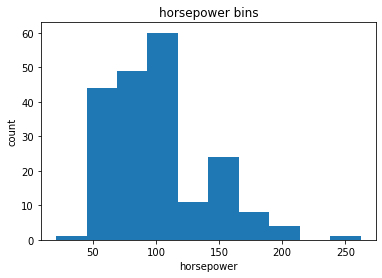

In [32]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot

plt.pyplot.hist(df["horsepower"])

# Set x/y labels and plot title
plt.pyplot.xlabel("horsepower")
plt.pyplot.ylabel("count")
plt.pyplot.title("horsepower bins")

We would like 3 bins of equal size bandwidth so we use numpy's ```np.linspace(start_value, end_value, numbers_generated)``` function.
- Since we want to include the minimum value of horsepower, we want to set **start_value = min(df["horsepower"])**.
- Since we want to include the maximum value of horsepower, we want to set **end_value = max(df["horsepower"])**.
- Since we are building 3 bins of equal length, there should be 4 dividers, so **numbers_generated = 4**, It's like ```|1|2|3|``` | = numbers_generated

We build a bin array with a minimum value to a maximum value by using the bandwidth calculated above. The values will determine when one bin ends and another begins.


In [33]:
bins = np.linspace(min(df["horsepower"]), max(df["horsepower"]), 4)
bins

array([ 21.        , 101.33333333, 181.66666667, 262.        ])

We set group  names:


In [34]:
group_names = ['Low', 'Medium', 'High']

We apply the function "cut" to determine what each value of `df['horsepower']` belongs to.

In [35]:
df['horsepower-binned'] = pd.cut(df['horsepower'], bins, labels=group_names, include_lowest=True )
df[['horsepower','horsepower-binned']].head(10)

,horsepower,horsepower-binned
0,21,Low
1,111,Medium
2,111,Medium
3,154,Medium
4,102,Medium
5,115,Medium
6,110,Medium
7,110,Medium
8,110,Medium
9,140,Medium


Let's see the number of vehicles in each bin:

In [36]:
df["horsepower-binned"].value_counts()

Low       116
Medium     76
High       10
Name: horsepower-binned, dtype: int64

Let's plot the distribution of each bin:

Text(0.5, 1.0, 'horsepower bins')

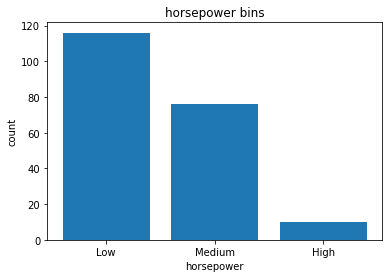

In [37]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot

pyplot.bar(group_names, df["horsepower-binned"].value_counts())

# Set x/y labels and plot title
plt.pyplot.xlabel("horsepower")
plt.pyplot.ylabel("count")
plt.pyplot.title("horsepower bins")

Look at the dataframe above carefully. You will find that the last column provides the bins for "horsepower" based on 3 categories ("Low", "Medium" and "High").  

We successfully narrowed down the intervals from 59 to 3!

### Bins Visualization
Normally, a histogram is used to visualize the distribution of bins we created above.

Text(0.5, 1.0, 'horsepower bins')

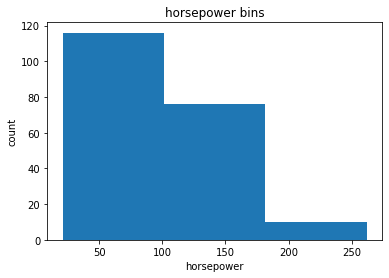

In [38]:
%matplotlib inline
import matplotlib as plt
from matplotlib import pyplot


# Draw historgram of attribute "horsepower" with bins = 3
plt.pyplot.hist(df["horsepower"], bins = 3)

# Set x/y labels and plot title
plt.pyplot.xlabel("horsepower")
plt.pyplot.ylabel("count")
plt.pyplot.title("horsepower bins")

The plot above shows the binning result for the attribute "horsepower".

### Indicator Variable (Dummy Variable)

An indicator variable (or dummy variable) is a numerical variable used to label categories. They are called 'dummies' because the numbers themselves don't have inherent meaning. 
  
Why we use indicator variables?
- We use indicator variables so we can use categorical variables for regression analysis in the later modules.

**Example**
  
We see the column "fuel-type" has two unique values: "gas" or "diesel". Regression doesn't understand words, only numbers. To use this attribute in regression analysis, we convert "fuel-type" to indicator variables.
- We will use pandas'method ```get_dummies``` to assign numerical values to different categories of fuel type.

In [39]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-L/100km', 'price', 'city-L/100km', 'horsepower-binned'],
      dtype='object')

Get the indicator variables and assign it to data frame "dummy_variable\_1":

In [40]:
dummy_variable_1 = pd.get_dummies(df["fuel-type"])
dummy_variable_1.head()

,3,diesel,gas
0,1,0,0
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1


Change the column names for clarity:

In [41]:
dummy_variable_1.rename(columns={'gas':'fuel-type-gas', 'diesel':'fuel-type-diesel'}, inplace=True)
dummy_variable_1.head()

,3,fuel-type-diesel,fuel-type-gas
0,1,0,0
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1


In the dataframe, column 'fuel-type' has values for 'gas' and 'diesel' as 0s and 1s now.


In [42]:
# Merge data frame "df" and "dummy_variable_1" 
df = pd.concat([df, dummy_variable_1], axis=1)

# Drop original column "fuel-type" from "df"
df.drop("fuel-type", axis = 1, inplace=True)

In [43]:
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,horsepower,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,horsepower-binned,3,fuel-type-diesel,fuel-type-gas
0,0,1,2,4,5,6,7,8,9.0,0.048054,...,21,22.0,23,9.791667,25.0,10.217391,Low,1,0,0
1,3,121,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,111,5000.0,21,8.703704,13495.0,11.190476,Medium,0,0,1
2,3,121,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,111,5000.0,21,8.703704,16500.0,11.190476,Medium,0,0,1
3,1,121,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,154,5000.0,19,9.038462,16500.0,12.368421,Medium,0,0,1
4,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,102,5500.0,24,7.833333,13950.0,9.791667,Medium,0,0,1


The last two columns are now the indicator variable representation of the fuel-type variable. They're all 0s and 1s now.


Create an indicator variable for the column "aspiration"

In [44]:
# Get indicator variables of aspiration and assign it to data frame "dummy_variable_2"
dummy_variable_2 = pd.get_dummies(df["aspiration"])
dummy_variable_2

,4,std,turbo
0,1,0,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0
...,...,...,...
197,0,1,0
198,0,0,1
199,0,1,0
200,0,0,1


In [45]:
# Change column names for clarity
dummy_variable_2.rename(columns={'std':'aspiration-std', 'turbo': 'aspiration-turbo'}, inplace=True)

# show first 5 instances of data frame "dummy_variable_1"
dummy_variable_2.head()

,4,aspiration-std,aspiration-turbo
0,1,0,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


Merge the new dataframe to the original dataframe, then drop the column 'aspiration'.

In [46]:
# Merge the new dataframe to the original datafram
df = pd.concat([df, dummy_variable_2], axis=1)

# Drop original column "aspiration" from "df"
df.drop('aspiration', axis = 1, inplace=True)

Save the new csv:

In [47]:
df.to_csv('D:\Github\DataAnalysis\Dataset\clean_df.csv')